In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Upload & Explore Datasets

In [2]:
monthly_revenue = pd.read_csv('monthly_revenue.csv')
subscriptions = pd.read_csv('subscriptions.csv')

In [3]:
monthly_revenue.shape

(48, 8)

In [4]:
subscriptions.shape

(600, 17)

In [5]:
monthly_revenue.head()

,month,total_active_customers,new_customers,churned_customers,monthly_churn_rate_pct,total_mrr,avg_revenue_per_customer,customer_acquisition_cost
0,2022-01,0,5,0,0.00,0.00,0.00,164.92
1,2022-02,5,10,1,20.00,7333.07,1466.61,189.21
2,2022-03,14,13,0,0.00,12301.16,878.65,139.49
3,2022-04,28,11,3,10.71,24798.76,885.67,259.09
4,2022-05,35,11,1,2.86,29091.88,831.20,152.96


In [6]:
subscriptions.head()

,customer_id,plan,billing_cycle,industry,company_size,seats,monthly_revenue,acquisition_channel,region,signup_date,churned,churn_date,churn_reason,support_tickets_12mo,nps_score,feature_usage_pct,upgraded
0,CUST-0001,Professional,Monthly,Retail,51-200,64,825.55,Organic Search,North America,2022-06-27,Yes,2024-03-05,Price Too High,13,3,15,No
1,CUST-0002,Professional,Annual,Retail,51-200,35,409.62,Direct Sales,North America,2023-03-19,No,NaN,NaN,1,3,52,Yes
2,CUST-0003,Starter,Annual,Finance,500+,266,1004.49,Partner,North America,2024-10-19,Yes,2025-04-13,Price Too High,10,4,31,No
3,CUST-0004,Business,Annual,Real Estate,11-50,34,1006.44,Partner,Europe,2023-01-07,No,NaN,NaN,3,7,58,No
4,CUST-0005,Starter,Annual,Manufacturing,51-200,48,198.43,Direct Sales,North America,2025-09-23,No,NaN,NaN,3,7,59,No


In [7]:
monthly_revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     object 
 1   total_active_customers     48 non-null     int64  
 2   new_customers              48 non-null     int64  
 3   churned_customers          48 non-null     int64  
 4   monthly_churn_rate_pct     48 non-null     float64
 5   total_mrr                  48 non-null     float64
 6   avg_revenue_per_customer   48 non-null     float64
 7   customer_acquisition_cost  48 non-null     float64
dtypes: float64(4), int64(3), object(1)
memory usage: 3.1+ KB


No null values in monthly_revenue.

In [8]:
subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           600 non-null    object 
 1   plan                  600 non-null    object 
 2   billing_cycle         600 non-null    object 
 3   industry              600 non-null    object 
 4   company_size          600 non-null    object 
 5   seats                 600 non-null    int64  
 6   monthly_revenue       600 non-null    float64
 7   acquisition_channel   600 non-null    object 
 8   region                600 non-null    object 
 9   signup_date           600 non-null    object 
 10  churned               600 non-null    object 
 11  churn_date            313 non-null    object 
 12  churn_reason          313 non-null    object 
 13  support_tickets_12mo  600 non-null    int64  
 14  nps_score             600 non-null    int64  
 15  feature_usage_pct     6

287 null values in churn_date and churn_reason, because these are customers who haven't churned.

In [9]:
monthly_revenue.describe()

,total_active_customers,new_customers,churned_customers,monthly_churn_rate_pct,total_mrr,avg_revenue_per_customer,customer_acquisition_cost
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,167.416667,12.500000,6.520833,4.518958,174888.413958,1010.218958,200.040625
std,85.274234,3.339002,3.414547,3.251457,92619.227429,175.723630,52.694255
min,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,122.990000
25%,104.000000,10.750000,4.000000,3.007500,102605.177500,1009.865000,150.267500
50%,184.500000,13.000000,7.000000,3.755000,190681.445000,1030.135000,197.250000
75%,241.750000,14.250000,8.250000,4.552500,262177.912500,1072.027500,249.187500
max,281.000000,19.000000,17.000000,20.000000,292628.610000,1466.610000,279.590000


In [10]:
subscriptions.describe()

,seats,monthly_revenue,support_tickets_12mo,nps_score,feature_usage_pct
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,42.450000,817.654300,6.480000,4.365000,40.638333
std,51.279823,1352.584783,4.271613,2.650185,22.749801
min,1.000000,24.650000,0.000000,1.000000,10.000000
25%,7.000000,137.137500,3.000000,2.000000,22.750000
50%,26.000000,348.250000,6.000000,4.000000,36.000000
75%,58.000000,874.832500,10.000000,6.000000,50.000000
max,297.000000,10978.000000,15.000000,10.000000,95.000000


# 1. What is the overall churn rate, and how has the monthly churn rate trended over the past 4 years? Is churn improving or getting worse?

In [11]:
# Overall churn rate = total churned customers / total customers

churn_rate = (sum(subscriptions['churned'] == 'Yes') / subscriptions.shape[0]) * 100
print(churn_rate)

52.166666666666664


Overall churn rate = 52.17% (2dp) 

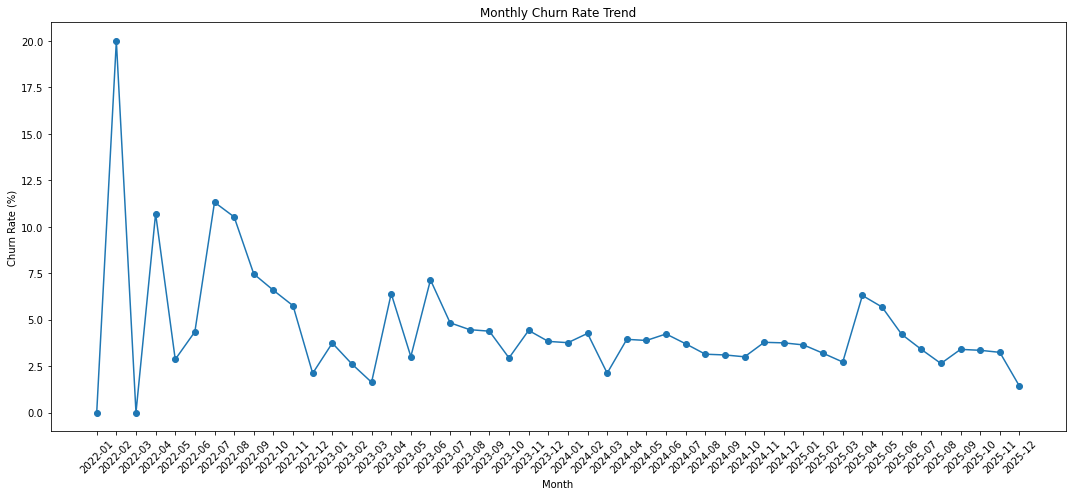

In [12]:
# Monthly churn rate trend over the 4 years
# monthly_churn_rate_pct in monthly_revenue
# Line graph where x = month and y = monthly_churn_rate_pct

plt.figure(figsize=(15, 7))
plt.plot(monthly_revenue['month'], monthly_revenue['monthly_churn_rate_pct'], marker='o')

plt.title('Monthly Churn Rate Trend')
plt.xlabel('Month')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The overall churn rate across the 4-year period is 52.17% (2dp).

The monthly churn rate has decreased overtime (past 4 years). In the first year, monthly churn rate was generally higher because there were fewer customers so it had a bigger impact on churn rate if a customer churned. 

After the first year, churn rate sits between 0 - 7.5%

Churn is improving as the 'Monthly Churn Rate Trend' graph shows that churn rate is slowly decreasing overtime.

Additionally, there are spikes where monthly churn rate increases every April. This could be because most companies begin their financial calendars in April. So, this may be where they review if they would like to keep their subscriptions or cancel them. Therefore, it should be expected that every April there will be a spike in churn rate. 

# 2. Which subscription plan (Starter, Professional, Business, Enterprise) has the highest churn rate? Does billing cycle (monthly vs. annual) significantly impact retention?

plan
Business        41.250000
Enterprise      22.000000
Professional    47.976879
Starter         70.506912
Name: churned, dtype: float64


<AxesSubplot:title={'center':'Churn Rate Per Plan'}, xlabel='Subscription Plan', ylabel='Churn Rate (%)'>

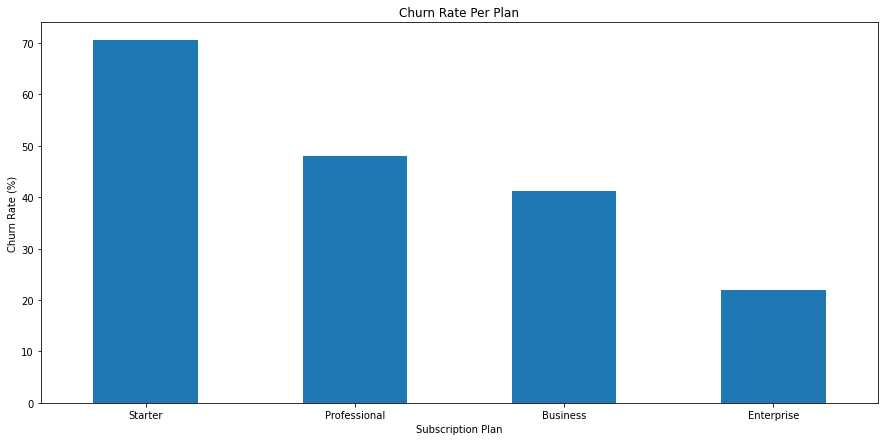

In [13]:
# Calculate churn rates for each plan

plan_churn_rate = subscriptions.groupby('plan')['churned'].apply(lambda x: (x == 'Yes').mean() * 100)

print(plan_churn_rate)

plan_churn_rate = plan_churn_rate.reindex(['Starter', 'Professional', 'Business', 'Enterprise'])

# Plot a bar chart where x = plan, y = churn rate
plan_churn_rate.plot(kind='bar', title='Churn Rate Per Plan', xlabel='Subscription Plan', ylabel='Churn Rate (%)', figsize=(15, 7), rot=0)

Customers with the 'Starter' subscription plan have the highest churn rate of 70.51% (2dp), significantly more than the others, making it the highest-risk plan.

It's followed by 'Professional' then 'Business' then 'Enterprise'.
This is likely because starters usually consist of individuals. They may just be testing out the software for fun or personal reasons, so they are less commited and reliant on it. Whereas, customers using it for work rely on it heavily as it is a necessity to them. 

billing_cycle
Annual     40.322581
Monthly    60.511364
Name: churned, dtype: float64


<AxesSubplot:title={'center':'Churn Rate Per Billing Cycle'}, xlabel='Billing Cycle', ylabel='Churn Rate (%)'>

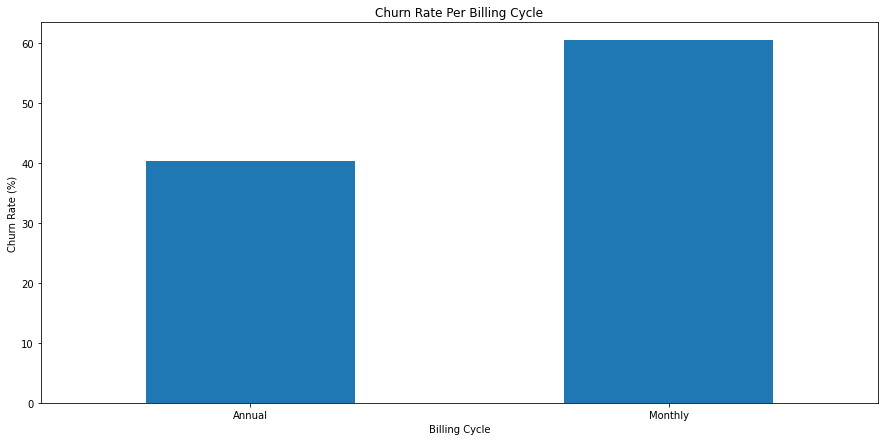

In [14]:
# Does billing cycle (monthly vs. annual) significantly impact retention?
# billing_cycle and churned in subscriptions

# Calculate churn rates for each billing cycle

billing_cycle_churn_rate = subscriptions.groupby('billing_cycle')['churned'].apply(lambda x: (x == 'Yes').mean() * 100)

print(billing_cycle_churn_rate)

# Plot a bar chart where x = billing cycle, y = churn rate

billing_cycle_churn_rate.plot(kind='bar', title='Churn Rate Per Billing Cycle', xlabel='Billing Cycle', ylabel='Churn Rate (%)', figsize=(15, 7), rot=0)

The monthly billing cycle has about 20% more churn rate than the annual one, making it higher risk.

This could be because customers with monthly cycles are less committed to using the software for a long period of time to begin with. Therefore, they are more likely to cancel their subscription. They also have more chances to cancel their subscriptions (12 times as opposed to 1 time).

# 3. What are the top 3 reasons customers churn, and do these reasons differ by plan type or company size?

In [15]:
# churn_reason in subscriptions

subscriptions.groupby('churn_reason')['customer_id'].count().sort_values(ascending=False)

churn_reason
Budget Cuts            53
Price Too High         51
Company Closed         48
Poor Support           42
No Longer Needed       41
Missing Features       40
Switched Competitor    38
Name: customer_id, dtype: int64

Top 3 reasons customers churn: Budget Cuts, Price Too High, Company Closed

Two of them relate to the software no longer being affordable for the customer.

<AxesSubplot:title={'center':'Churn Reasons by Plan'}, xlabel='Subscription Plan', ylabel='Number of customers'>

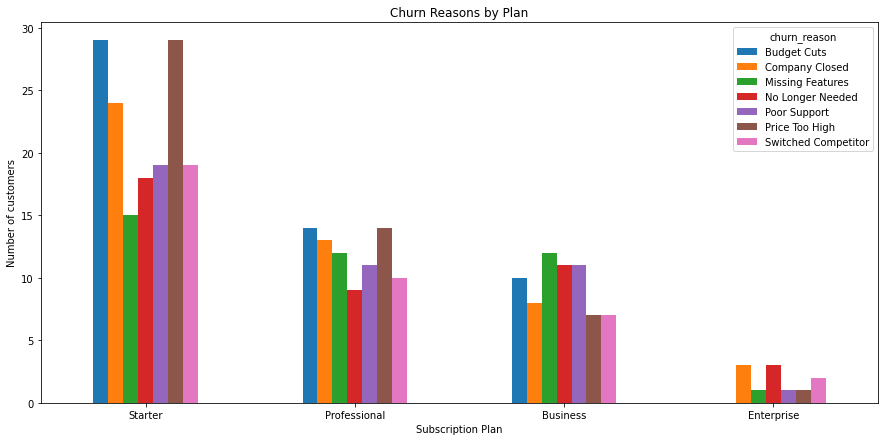

In [16]:
# Clustered bar chart to see how churn reasons differ by subscription plan

churn_reason_plan = subscriptions[subscriptions['churned'] == 'Yes'].groupby(['plan', 'churn_reason']).size().unstack()

churn_reason_plan = churn_reason_plan.reindex(['Starter', 'Professional', 'Business', 'Enterprise'])

churn_reason_plan.plot(kind='bar', title='Churn Reasons by Plan', xlabel='Subscription Plan', ylabel='Number of customers', figsize=(15, 7), rot=0)

Top 3 churn reasons by subscription plan:

Starter - Budget cuts, Price too high, Company closed

Professional - Budget cuts, Price too high, Company closed

Business - Missing features, No longer needed, Poor support

Enterprise - Company closed, No longer needed, Switched competitor

The top churn reasons do differ by subscription plan. The customers who were on 'Starter' and 'Professional' plans have the same top 3 reasons. Most of them relating to finances and unaffordability of the product. Whereas, customers who were on the 'Enterprise' and 'Business' plans don't have these reasons as they are bigger businesses that are able to afford the product more comfortably. They tend to leave because they either don't need the product anymore or aren't happy with it anymore.

<AxesSubplot:title={'center':'Churn Reasons by Company Size'}, xlabel='Company Size', ylabel='Number of customers'>

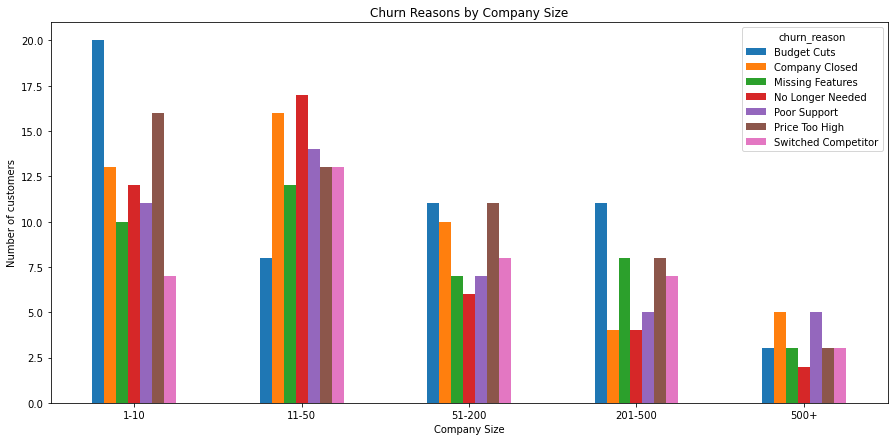

In [17]:
# Clustered bar chart to see how churn reasons differ by company size

churn_reason_company_size = subscriptions[subscriptions['churned'] == 'Yes'].groupby(['company_size', 'churn_reason']).size().unstack()

churn_reason_company_size = churn_reason_company_size.reindex(['1-10', '11-50', '51-200', '201-500', '500+'])

churn_reason_company_size.plot(kind='bar', title = 'Churn Reasons by Company Size', xlabel = 'Company Size', ylabel = 'Number of customers', figsize=(15,7), rot=0)

Top 3 churn reasons by company size:

1-10 - Budget cuts, Price too high, Company closed

11-50 - No longer needed, Company closed, Poor support

51-200 - Budget cuts, Price too high, Company closed

201-500 - Budget cuts, Missing features, Price too high

500+ - Company closed, Poor support, third is a tie between 4 reasons

The top churn reasons do differ by company size. However, company closing is a reason for all company sizes, except medium size companies (201-500). Therefore, there is no guarantee that the bigger a company is, the less likely it is to churn because it closed. It also seems all company sizes have financial reasons for churning, except companies that are really big (500+) and small companies (11-50). Additionally, these company sizes (11-50 and 500+) tend to churn due to poor support and no longer needing the product.

# 4. Calculate the average Customer Lifetime Value (CLV) by plan. Compare this to the Customer Acquisition Cost (CAC). Which plans are the most and least profitable?

In [18]:
# Calculate CLV for every customer
# CLV = monthly revenue x months between sign up date and churn date

# Set churn_dates to 2025-12-31 where it's NaN
subscriptions['churn_date'] = subscriptions['churn_date'].fillna('2025-12-31')

subscriptions['churn_date'] = pd.to_datetime(subscriptions['churn_date'])
subscriptions['signup_date'] = pd.to_datetime(subscriptions['signup_date'])

# Calculate lifespan_months
subscriptions['lifespan_months'] = (subscriptions['churn_date'] - subscriptions['signup_date']).dt.days / 30

# Create CLV column
subscriptions['clv'] = subscriptions['monthly_revenue'] * subscriptions['lifespan_months']

plan
Business        21899.730617
Enterprise      66738.140487
Professional     8138.932303
Starter          1878.938651
Name: clv, dtype: float64


<AxesSubplot:title={'center':'Average CLV by Plan'}, xlabel='plan'>

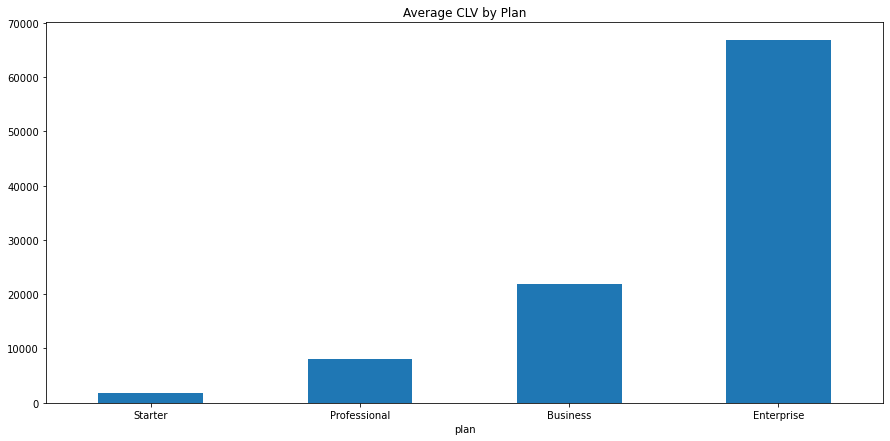

In [19]:
# Plot bar chart for average CLV by plan

average_clv_by_plan = subscriptions.groupby('plan')['clv'].mean()
print(average_clv_by_plan)

average_clv_by_plan = average_clv_by_plan.reindex(['Starter','Professional', 'Business', 'Enterprise'])

average_clv_by_plan.plot(kind='bar', title='Average CLV by Plan', figsize=(15,7), rot=0)

In [20]:
# Calculate CAC per customer
# customer_acquisition_cost in monthly_revenue
# Cannot calculate CAC by plan, only average CAC per customer

average_cac = monthly_revenue['customer_acquisition_cost'].sum() / monthly_revenue['new_customers'].sum()
print('Average CAC:', average_cac)
print('Total CAC:', monthly_revenue['customer_acquisition_cost'].sum())
print('Total Revenue:', monthly_revenue['total_mrr'].sum())

Average CAC: 16.00325
Total CAC: 9601.95
Total Revenue: 8394643.870000001


Average CLV by plan / Most to least profitable:

Enterprise: 66738.14 (2dp)

Business: 21899.73 (2dp)

Professional: 8138.93 (2dp)

Starter: 1878.94 (2dp)

Most profitable plans are where the customers buy 'Business' or 'Enterprise' plans. This may be because these plans are more expensive than the others ('Professional' & 'Starter'), so they bring in more revenue. Also, these customers may have longer lifespans using the product, have annual subscriptions, churn less. All of these reasons lead to these customers having much higher average CLV. As a result, the company should try to acquire as many big businesses that will need 'Business' & 'Enterprise' subscription plans as possible.

Average CAC per customer is 16.00 (2dp). This is very low compared to the Average CLV by plan. Therefore the CLV:CAC ratio is is very healthy for this company and customer acquisition efforts are profitable. The Total CAC for all 600 customers is 9601.95. In comparison, the total revenue from all 600 customers is 8394643.87 (2dp). 